# Evaluate all trained models on June 17 bacterial samples

This notebook loads every trained model artifact found in `models/trained`, runs predictions on the parsed June 17 bacterial samples, and creates a brief model comparison table.

It is designed to work with scikit-learn/joblib models and PyTorch checkpoints. For the June 17 folders, `bacillus_cereus_possible` is mapped to `B_cereus` and `micrococcus` is mapped to `M_luteus`.

In [35]:
from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Any

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except Exception:
    MATPLOTLIB_AVAILABLE = False

print("Torch available:", TORCH_AVAILABLE)


Torch available: True


In [36]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix

TRAINED_DIR = Path(
    r"C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\models\trained"
)

PARSED_DIR = Path(
    r"C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\data\live_rapid_e\parsed"
)

RESULTS_DIR = Path(
    r"C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\live_rapid_e\model_comparison"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILES = [
    PARSED_DIR / "june17_bacillus_cereus_possible_preprocessed.parquet",
    PARSED_DIR / "june17_micrococcus_preprocessed.parquet",
]

df = pd.concat([pd.read_parquet(p) for p in DATA_FILES], ignore_index=True)

df["true_label"] = df["expected_sample"].map({
    "B_cereus": "B_cereus",
    "M_luteus": "M_luteus",
    "bacillus_cereus_possible": "B_cereus",
    "micrococcus": "M_luteus",
}).fillna(df["expected_sample"])

df.shape

(53, 1978)

In [37]:
def get_feature_blocks(df: pd.DataFrame) -> dict[str, list[str]]:
    fs_cols = sorted([c for c in df.columns if c.startswith("fs_")])
    lt_cols = sorted([c for c in df.columns if c.startswith("lt_")])
    si_cols = sorted([c for c in df.columns if c.startswith("si_")])
    scalar_cols = [c for c in ["size", "time_asymmetry"] if c in df.columns]

    return {
        "fs": fs_cols,
        "lt": lt_cols,
        "si": si_cols,
        "scalar": scalar_cols,
        "fs_lt": fs_cols + lt_cols,
        "fs_lt_scalar": fs_cols + lt_cols + scalar_cols,
        "all": fs_cols + lt_cols + si_cols + scalar_cols,
    }


FEATURE_BLOCKS = get_feature_blocks(df)

{k: len(v) for k, v in FEATURE_BLOCKS.items()}

{'fs': 256,
 'lt': 256,
 'si': 1440,
 'scalar': 2,
 'fs_lt': 512,
 'fs_lt_scalar': 514,
 'all': 1954}

In [38]:
def find_label_encoder(model_path: Path):
    candidates = [
        model_path.parent / "label_encoder.joblib",
        model_path.parent.parent / "label_encoder.joblib",
    ]

    for p in candidates:
        if p.exists():
            return joblib.load(p)

    return None


def select_features_for_sklearn_model(model, feature_blocks: dict[str, list[str]]) -> tuple[str, list[str]]:
    expected_n = getattr(model, "n_features_in_", None)

    if expected_n is None:
        raise ValueError("Cannot determine expected feature count for sklearn model.")

    exact_matches = [
        (name, cols)
        for name, cols in feature_blocks.items()
        if len(cols) == expected_n
    ]

    if exact_matches:
        return exact_matches[0]

    raise ValueError(
        f"No feature block matches model expected input size {expected_n}. "
        f"Available blocks: { {k: len(v) for k, v in feature_blocks.items()} }"
    )


def normalize_label(label: str) -> str:
    label = str(label)

    replacements = {
        "B. cereus": "B_cereus",
        "B_cereus": "B_cereus",
        "Bacillus cereus": "B_cereus",
        "M. luteus": "M_luteus",
        "M_luteus": "M_luteus",
        "Micrococcus luteus": "M_luteus",
        "micrococcus": "M_luteus",
    }

    return replacements.get(label, label)

In [39]:
def find_model_files(trained_dir: Path) -> list[Path]:
    model_files = []

    for path in trained_dir.rglob("*"):
        if path.name in {"model.joblib", "model.pt"}:
            model_files.append(path)

    return sorted(model_files)


model_files = find_model_files(TRAINED_DIR)
model_files

[WindowsPath('C:/Users/chris/OneDrive/Documents/Universitat de Barcelona/lif_thesis/models/trained/exp00_paper_rf_v1/model.joblib'),
 WindowsPath('C:/Users/chris/OneDrive/Documents/Universitat de Barcelona/lif_thesis/models/trained/exp01_grouped_paper_rf_v1/model.joblib'),
 WindowsPath('C:/Users/chris/OneDrive/Documents/Universitat de Barcelona/lif_thesis/models/trained/exp02_grouped_engineered_rf_v1/model.joblib'),
 WindowsPath('C:/Users/chris/OneDrive/Documents/Universitat de Barcelona/lif_thesis/models/trained/exp03_tuned_rf_v1/model.joblib'),
 WindowsPath('C:/Users/chris/OneDrive/Documents/Universitat de Barcelona/lif_thesis/models/trained/exp04_baseline_cnn_v1/model.pt'),
 WindowsPath('C:/Users/chris/OneDrive/Documents/Universitat de Barcelona/lif_thesis/models/trained/exp05_multimodal_species_v1/model.pt'),
 WindowsPath('C:/Users/chris/OneDrive/Documents/Universitat de Barcelona/lif_thesis/models/trained/exp06_robust_multimodal_species_v1/model.pt')]

In [40]:
def evaluate_sklearn_model(model_path: Path, df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    model = joblib.load(model_path)

    if not hasattr(model, "predict"):
        raise TypeError(f"{model_path.name} is not a predictive model.")

    block_name, feature_cols = select_features_for_sklearn_model(model, FEATURE_BLOCKS)

    X = df[feature_cols].to_numpy(dtype=np.float32)

    pred = model.predict(X)

    label_encoder = find_label_encoder(model_path)
    if label_encoder is not None:
        try:
            pred = label_encoder.inverse_transform(pred)
        except Exception:
            pass

    pred = [normalize_label(x) for x in pred]
    true = [normalize_label(x) for x in df["true_label"]]

    pred_df = df[["experiment_name", "expected_sample", "true_label", "raw_file", "particle_index"]].copy()
    pred_df["model_path"] = str(model_path)
    pred_df["model_name"] = model_path.parent.name
    pred_df["feature_block"] = block_name
    pred_df["predicted_label"] = pred

    metrics = {
        "model_name": model_path.parent.name,
        "model_path": str(model_path),
        "model_type": "sklearn",
        "feature_block": block_name,
        "n_features": len(feature_cols),
        "n_particles": len(df),
        "accuracy": accuracy_score(true, pred),
        "balanced_accuracy": balanced_accuracy_score(true, pred),
        "macro_f1": f1_score(true, pred, average="macro", zero_division=0),
        "unknown_fraction": float(np.mean(pd.Series(pred).eq("unknown"))),
    }

    return pred_df, pd.DataFrame([metrics])

In [41]:
all_predictions = []
all_metrics = []
failures = []

for model_path in model_files:
    if model_path.suffix != ".joblib":
        continue

    print(f"Evaluating: {model_path}")

    try:
        pred_df, metrics_df = evaluate_sklearn_model(model_path, df)
        all_predictions.append(pred_df)
        all_metrics.append(metrics_df)

        row = metrics_df.iloc[0]
        print(
            f"  accuracy={row['accuracy']:.4f} | "
            f"balanced_accuracy={row['balanced_accuracy']:.4f} | "
            f"macro_f1={row['macro_f1']:.4f} | "
            f"features={row['feature_block']} ({row['n_features']})"
        )

    except Exception as exc:
        failures.append({
            "model_path": str(model_path),
            "error": repr(exc),
        })
        print(f"  FAILED: {repr(exc)}")

metrics = pd.concat(all_metrics, ignore_index=True).sort_values(
    "balanced_accuracy",
    ascending=False,
)

predictions = pd.concat(all_predictions, ignore_index=True)

metrics

Evaluating: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\models\trained\exp00_paper_rf_v1\model.joblib
  accuracy=0.4717 | balanced_accuracy=0.5000 | macro_f1=0.3205 | features=fs (256)
Evaluating: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\models\trained\exp01_grouped_paper_rf_v1\model.joblib
  accuracy=0.4717 | balanced_accuracy=0.5000 | macro_f1=0.2165 | features=fs (256)
Evaluating: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\models\trained\exp02_grouped_engineered_rf_v1\model.joblib
  FAILED: ValueError("No feature block matches model expected input size 258. Available blocks: {'fs': 256, 'lt': 256, 'si': 1440, 'scalar': 2, 'fs_lt': 512, 'fs_lt_scalar': 514, 'all': 1954}")
Evaluating: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\models\trained\exp03_tuned_rf_v1\model.joblib
  accuracy=0.4340 | balanced_accuracy=0.4579 | macro_f1=0.2296 | features=fs_lt_scalar (514)


,model_name,model_path,model_type,feature_block,n_features,n_particles,accuracy,balanced_accuracy,macro_f1,unknown_fraction
0,exp00_paper_rf_v1,C:\Users\chris\OneDrive\Documents\Universitat ...,sklearn,fs,256,53,0.471698,0.500000,0.320513,0.0
1,exp01_grouped_paper_rf_v1,C:\Users\chris\OneDrive\Documents\Universitat ...,sklearn,fs,256,53,0.471698,0.500000,0.216450,0.0
2,exp03_tuned_rf_v1,C:\Users\chris\OneDrive\Documents\Universitat ...,sklearn,fs_lt_scalar,514,53,0.433962,0.457857,0.229561,0.0


In [42]:
metrics.to_csv(RESULTS_DIR / "june17_model_comparison_metrics.csv", index=False)
predictions.to_parquet(RESULTS_DIR / "june17_model_predictions.parquet", index=False)

pd.DataFrame(failures).to_csv(RESULTS_DIR / "june17_model_comparison_failures.csv", index=False)

metrics

,model_name,model_path,model_type,feature_block,n_features,n_particles,accuracy,balanced_accuracy,macro_f1,unknown_fraction
0,exp00_paper_rf_v1,C:\Users\chris\OneDrive\Documents\Universitat ...,sklearn,fs,256,53,0.471698,0.500000,0.320513,0.0
1,exp01_grouped_paper_rf_v1,C:\Users\chris\OneDrive\Documents\Universitat ...,sklearn,fs,256,53,0.471698,0.500000,0.216450,0.0
2,exp03_tuned_rf_v1,C:\Users\chris\OneDrive\Documents\Universitat ...,sklearn,fs_lt_scalar,514,53,0.433962,0.457857,0.229561,0.0


In [43]:
def find_sample_files() -> list[Path]:
    if PREFERRED_SAMPLE_FILE.exists():
        return [PREFERRED_SAMPLE_FILE]

    candidates = sorted(PARSED_DIR.glob("*.parquet"))
    keep = []
    for path in candidates:
        name = path.name.lower()
        if "june17" in name and (
            "bacillus_cereus_possible" in name
            or "micrococcus" in name
            or ("bacillus" in name and "micrococcus" in name)
        ):
            keep.append(path)

    if not keep:
        raise FileNotFoundError(
            f"No June 17 bacillus/micrococcus parquet files found in {PARSED_DIR}"
        )

    return keep


sample_files = find_sample_files()
print("Sample files:")
for path in sample_files:
    print(" -", path)

df = pd.concat([pd.read_parquet(path) for path in sample_files], ignore_index=True)
print("Loaded rows:", len(df))
print("Columns:", len(df.columns))
df.head()


Sample files:
 - C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\data\live_rapid_e\parsed\june17_bacillus_cereus_possible_micrococcus_preprocessed.parquet
Loaded rows: 53
Columns: 1977


,raw_file,raw_path,particle_index,timestamp,serial,version,number_of_modules,has_fluorescence,lt11_framelength,lt03_framelength,...,si_1433,si_1434,si_1435,si_1436,si_1437,si_1438,si_1439,experiment_date,expected_sample,expected_composition
0,D_000000155_202606171224.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,289,2026-06-17 14:24:10.359,3532891,2,3,True,960,256,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,2026-06-17,B_cereus,B_cereus_possible
1,D_000000156_202606171225.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,265,2026-06-17 14:25:13.295,3532891,2,3,True,936,256,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,2026-06-17,B_cereus,B_cereus_possible
2,D_000000156_202606171225.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,1156,2026-06-17 14:25:44.207,3532891,2,3,True,13680,256,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,2026-06-17,B_cereus,B_cereus_possible
3,D_000000156_202606171225.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,2387,2026-06-17 14:25:59.660,3532891,2,3,True,4296,256,...,0.001316,0.0,0.0,0.0,0.0,0.011194,0.0,2026-06-17,B_cereus,B_cereus_possible
4,D_000000158_202606171227.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,2115,2026-06-17 14:27:26.556,3532891,2,3,True,912,256,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,2026-06-17,B_cereus,B_cereus_possible


In [44]:
def normalize_label(value: Any) -> str | None:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None

    text = str(value).strip()

    mapping = {
        "B. cereus": "B_cereus",
        "B cereus": "B_cereus",
        "B_cereus": "B_cereus",
        "Bacillus cereus": "B_cereus",
        "bacillus_cereus_possible": "B_cereus",
        "B_cereus_possible": "B_cereus",
        "bacillus": "B_cereus",

        "M. luteus": "M_luteus",
        "M luteus": "M_luteus",
        "M_luteus": "M_luteus",
        "Micrococcus luteus": "M_luteus",
        "micrococcus": "M_luteus",

        "B. endophyticus": "B_endophyticus",
        "B_endophyticus": "B_endophyticus",
        "Bacillus endophyticus": "B_endophyticus",

        "K. salsicia": "K_salsicia",
        "K_salsicia": "K_salsicia",
        "Kocuria salsicia": "K_salsicia",

        "S. huminis": "S_huminis",
        "S_huminis": "S_huminis",
        "Staphylococcus huminis": "S_huminis",

        "control": "control",
        "ringer": "control",
        "distilled_water": "control",
        "water": "control",
        "unknown": "unknown",
    }

    return mapping.get(text, text)


def infer_truth_labels(data: pd.DataFrame) -> pd.Series:
    candidate_cols = [
        "expected_sample",
        "expected_label",
        "true_label",
        "label",
        "species",
        "experiment_name",
        "expected_composition",
    ]

    for col in candidate_cols:
        if col in data.columns:
            labels = data[col].map(normalize_label)
            if labels.notna().sum() > 0:
                print(f"Using truth labels from column: {col}")
                return labels

    raise ValueError(
        "Could not infer true labels. Add a column such as expected_sample, "
        "expected_label, true_label, label, species, or experiment_name."
    )


df["y_true"] = infer_truth_labels(df)
print(df["y_true"].value_counts(dropna=False))


Using truth labels from column: expected_sample
y_true
B_cereus    28
M_luteus    25
Name: count, dtype: int64


In [45]:
MODEL_EXTENSIONS = {".joblib", ".pkl", ".pickle", ".pt", ".pth"}

model_paths = sorted(
    path for path in TRAINED_MODELS_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in MODEL_EXTENSIONS
)

print(f"Found {len(model_paths)} model files")
for path in model_paths:
    print(" -", path.relative_to(TRAINED_MODELS_DIR))


Found 24 model files
 - exp00_paper_rf_v1\label_encoder.joblib
 - exp00_paper_rf_v1\model.joblib
 - exp01_grouped_paper_rf_v1\label_encoder.joblib
 - exp01_grouped_paper_rf_v1\model.joblib
 - exp02_grouped_engineered_rf_v1\label_encoder.joblib
 - exp02_grouped_engineered_rf_v1\model.joblib
 - exp03_tuned_rf_v1\label_encoder.joblib
 - exp03_tuned_rf_v1\model.joblib
 - exp04_baseline_cnn_v1\label_encoder.joblib
 - exp04_baseline_cnn_v1\model.pt
 - exp04_baseline_cnn_v1\spectra_scaler.joblib
 - exp05_multimodal_species_v1\label_encoder.joblib
 - exp05_multimodal_species_v1\lifetime_scaler.joblib
 - exp05_multimodal_species_v1\model.pt
 - exp05_multimodal_species_v1\scalar_scaler.joblib
 - exp05_multimodal_species_v1\scattering_scaler.joblib
 - exp05_multimodal_species_v1\spectrometer_scaler.joblib
 - exp06_robust_multimodal_species_v1\label_encoder.joblib
 - exp06_robust_multimodal_species_v1\lifetime_scaler.joblib
 - exp06_robust_multimodal_species_v1\model.pt
 - exp06_robust_multimodal_

In [46]:
def numeric_feature_columns(data: pd.DataFrame) -> list[str]:
    exclude_exact = {
        "y_true", "label", "true_label", "expected_label", "expected_sample",
        "expected_composition", "experiment_name", "experiment_date",
        "raw_file", "raw_path", "source_file", "source_path", "filename",
        "processed_at", "event_time", "timestamp", "batch_id", "model_name",
        "predicted_label", "robust_prediction", "closed_set_prediction",
    }

    return [
        col for col in data.columns
        if col not in exclude_exact and pd.api.types.is_numeric_dtype(data[col])
    ]


def prefix_columns(data: pd.DataFrame, prefixes: tuple[str, ...]) -> list[str]:
    return sorted([col for col in data.columns if col.startswith(prefixes)])


def get_feature_matrix(data: pd.DataFrame, model: Any | None = None) -> tuple[np.ndarray, list[str]]:
    if model is not None and hasattr(model, "feature_names_in_"):
        cols = [c for c in list(model.feature_names_in_) if c in data.columns]
        if cols:
            X = data[cols].replace([np.inf, -np.inf], np.nan).fillna(0)
            return X.to_numpy(dtype=np.float32), cols

    model_ready = prefix_columns(data, ("fs_", "lt_", "si_", "scat_", "scalar_"))

    scalar_cols = [
        c for c in ["size", "time_asymmetry", "peak_fluorescence"]
        if c in data.columns and pd.api.types.is_numeric_dtype(data[c])
    ]

    cols = model_ready + [c for c in scalar_cols if c not in model_ready]
    if not cols:
        cols = numeric_feature_columns(data)

    X = data[cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    return X.to_numpy(dtype=np.float32), cols


def get_modality_arrays(data: pd.DataFrame) -> dict[str, np.ndarray]:
    arrays = {}

    fs_cols = prefix_columns(data, ("fs_",))
    lt_cols = prefix_columns(data, ("lt_",))
    si_cols = prefix_columns(data, ("si_", "scat_"))

    scalar_cols = [
        c for c in ["size", "time_asymmetry", "peak_fluorescence"]
        if c in data.columns and pd.api.types.is_numeric_dtype(data[c])
    ]

    if fs_cols:
        arrays["spectra"] = data[fs_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(np.float32)
    if lt_cols:
        arrays["lifetime"] = data[lt_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(np.float32)
    if si_cols:
        arrays["scattering"] = data[si_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(np.float32)
    if scalar_cols:
        arrays["scalar"] = data[scalar_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(np.float32)

    return arrays


In [47]:
DEFAULT_CLASS_NAMES = [
    "B_cereus",
    "B_endophyticus",
    "K_salsicia",
    "M_luteus",
    "S_huminis",
]


def load_label_mapping_for_model(model_path: Path) -> list[str] | None:
    candidates = [
        LABEL_MAPS_DIR / f"{model_path.stem}_labels.json",
        LABEL_MAPS_DIR / f"{model_path.stem}.json",
        model_path.with_suffix(".json"),
    ]

    if LABEL_MAPS_DIR.exists():
        candidates.extend(sorted(LABEL_MAPS_DIR.glob(f"*{model_path.stem}*labels*.json")))
        candidates.extend(sorted(LABEL_MAPS_DIR.glob(f"*{model_path.stem}*.json")))

    for path in candidates:
        if not path.exists():
            continue

        try:
            obj = json.loads(path.read_text(encoding="utf-8"))
            if isinstance(obj, list):
                return [normalize_label(x) for x in obj]
            if isinstance(obj, dict):
                if all(str(k).isdigit() for k in obj.keys()):
                    return [normalize_label(obj[str(i)]) for i in range(len(obj))]
                if all(isinstance(v, int) for v in obj.values()):
                    inv = {v: k for k, v in obj.items()}
                    return [normalize_label(inv[i]) for i in range(len(inv))]
        except Exception:
            pass

    return None


def labels_from_prediction_indices(indices: np.ndarray, class_names: list[str] | None) -> np.ndarray:
    if class_names is None:
        class_names = DEFAULT_CLASS_NAMES

    out = []
    for idx in indices:
        idx = int(idx)
        if 0 <= idx < len(class_names):
            out.append(normalize_label(class_names[idx]))
        else:
            out.append(str(idx))

    return np.array(out, dtype=object)


def normalize_predictions(pred: Any, class_names: list[str] | None = None) -> np.ndarray:
    arr = np.asarray(pred)

    if arr.ndim == 2:
        arr = arr.argmax(axis=1)

    if np.issubdtype(arr.dtype, np.number):
        return labels_from_prediction_indices(arr, class_names)

    return np.array([normalize_label(x) for x in arr], dtype=object)


In [48]:
class GenericMLP(nn.Module if TORCH_AVAILABLE else object):
    def __init__(self, input_dim: int, n_classes: int):
        if not TORCH_AVAILABLE:
            raise RuntimeError("Torch is not available.")
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def try_import_repo_torch_model(checkpoint: dict[str, Any], input_dim: int, n_classes: int):
    architecture = str(checkpoint.get("architecture", "")).lower()
    model_name = str(checkpoint.get("model_name", "")).lower()

    try:
        from lif_thesis.experiments.exp06_robust_cnn import RobustMultimodalCNN
        if "robust" in architecture or "robust" in model_name:
            return RobustMultimodalCNN(n_classes=n_classes)
    except Exception:
        pass

    try:
        from lif_thesis.experiments.exp05_multimodal_deep_learning import MultimodalSpeciesCNN
        if "multimodal" in architecture or "multimodal" in model_name:
            return MultimodalSpeciesCNN(n_classes=n_classes)
    except Exception:
        pass

    return None


def load_torch_checkpoint(model_path: Path, data: pd.DataFrame):
    if not TORCH_AVAILABLE:
        raise RuntimeError("Torch is not available in this environment.")

    checkpoint = torch.load(model_path, map_location="cpu")

    if isinstance(checkpoint, nn.Module):
        checkpoint.eval()
        class_names = load_label_mapping_for_model(model_path)
        return checkpoint, class_names, checkpoint

    if not isinstance(checkpoint, dict):
        raise TypeError("Unsupported torch checkpoint format.")

    class_names = checkpoint.get("class_names") or checkpoint.get("classes")
    if class_names is not None:
        class_names = [normalize_label(x) for x in class_names]
    else:
        class_names = load_label_mapping_for_model(model_path)

    n_classes = int(checkpoint.get("n_classes") or (len(class_names) if class_names else len(DEFAULT_CLASS_NAMES)))

    X_tab, feature_cols = get_feature_matrix(data)
    input_dim = X_tab.shape[1]

    model = try_import_repo_torch_model(checkpoint, input_dim=input_dim, n_classes=n_classes)
    if model is None:
        model = GenericMLP(input_dim=input_dim, n_classes=n_classes)

    state = checkpoint.get("model_state_dict") or checkpoint.get("state_dict") or checkpoint.get("model") or checkpoint
    model.load_state_dict(state, strict=False)
    model.eval()

    return model, class_names, checkpoint


def predict_torch_model(model_path: Path, data: pd.DataFrame, batch_size: int = 512) -> tuple[np.ndarray, np.ndarray | None]:
    model, class_names, checkpoint = load_torch_checkpoint(model_path, data)

    X_tab, feature_cols = get_feature_matrix(data)
    X_tensor = torch.tensor(X_tab, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)

    logits_all = []

    with torch.no_grad():
        for (xb,) in loader:
            out = model(xb)

            if isinstance(out, tuple):
                out = out[0]
            if isinstance(out, dict):
                out = out.get("logits") or out.get("output") or out.get("pred")

            logits_all.append(out.detach().cpu())

    logits = torch.cat(logits_all, dim=0).numpy()

    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    proba = exp / exp.sum(axis=1, keepdims=True)

    pred_idx = logits.argmax(axis=1)
    labels = labels_from_prediction_indices(pred_idx, class_names)

    return labels, proba


In [49]:
def predict_sklearn_model(model_path: Path, data: pd.DataFrame) -> tuple[np.ndarray, np.ndarray | None]:
    model = joblib.load(model_path)

    X, cols = get_feature_matrix(data, model=model)

    raw_pred = model.predict(X)
    class_names = None

    if hasattr(model, "classes_"):
        class_names = [normalize_label(x) for x in list(model.classes_)]

    pred_labels = normalize_predictions(raw_pred, class_names=class_names)

    proba = None
    if hasattr(model, "predict_proba"):
        try:
            proba = model.predict_proba(X)
        except Exception:
            proba = None

    return pred_labels, proba


def predict_model(model_path: Path, data: pd.DataFrame) -> dict[str, Any]:
    suffix = model_path.suffix.lower()
    model_id = model_path.stem

    if suffix in {".joblib", ".pkl", ".pickle"}:
        pred, proba = predict_sklearn_model(model_path, data)
        model_type = "sklearn/joblib"
    elif suffix in {".pt", ".pth"}:
        pred, proba = predict_torch_model(model_path, data)
        model_type = "torch"
    else:
        raise ValueError(f"Unsupported model type: {model_path}")

    return {
        "model_id": model_id,
        "model_path": str(model_path),
        "model_type": model_type,
        "prediction": pred,
        "proba": proba,
    }


In [50]:
def evaluate_predictions(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, Any]:
    pred_series = pd.Series(y_pred, index=y_true.index)
    mask = y_true.notna() & pred_series.notna()

    yt = y_true[mask].astype(str).to_numpy()
    yp = pred_series[mask].astype(str).to_numpy()

    known_mask = yp != "unknown"

    metrics = {
        "n_particles": int(mask.sum()),
        "unknown_fraction": float((yp == "unknown").mean()) if len(yp) else np.nan,
        "accuracy": float(accuracy_score(yt, yp)) if len(yp) else np.nan,
        "balanced_accuracy": float(balanced_accuracy_score(yt, yp)) if len(yp) else np.nan,
        "macro_f1": float(f1_score(yt, yp, average="macro")) if len(yp) else np.nan,
    }

    if known_mask.sum() > 0:
        metrics["known_only_accuracy"] = float(accuracy_score(yt[known_mask], yp[known_mask]))
        metrics["known_only_balanced_accuracy"] = float(balanced_accuracy_score(yt[known_mask], yp[known_mask]))
    else:
        metrics["known_only_accuracy"] = np.nan
        metrics["known_only_balanced_accuracy"] = np.nan

    return metrics


results = []
prediction_frames = []

for model_path in model_paths:
    print(f"\nEvaluating: {model_path.name}")

    try:
        out = predict_model(model_path, df)
        pred = out["prediction"]
        metrics = evaluate_predictions(df["y_true"], pred)

        row = {
            "model_id": out["model_id"],
            "model_type": out["model_type"],
            "model_path": out["model_path"],
            **metrics,
        }
        results.append(row)

        pred_df = pd.DataFrame({
            "model_id": out["model_id"],
            "raw_file": df["raw_file"] if "raw_file" in df.columns else None,
            "particle_index": df["particle_index"] if "particle_index" in df.columns else np.arange(len(df)),
            "experiment_name": df["experiment_name"] if "experiment_name" in df.columns else None,
            "y_true": df["y_true"],
            "y_pred": pred,
        })

        if out["proba"] is not None:
            pred_df["prediction_confidence"] = np.max(out["proba"], axis=1)

        prediction_frames.append(pred_df)

        print("  accuracy:", round(row["accuracy"], 4))
        print("  balanced accuracy:", round(row["balanced_accuracy"], 4))
        print("  macro F1:", round(row["macro_f1"], 4))
        print("  unknown fraction:", round(row["unknown_fraction"], 4))

    except Exception as exc:
        print("  FAILED:", repr(exc))
        results.append({
            "model_id": model_path.stem,
            "model_type": model_path.suffix.lower(),
            "model_path": str(model_path),
            "error": repr(exc),
        })

comparison = pd.DataFrame(results)

if not comparison.empty and "balanced_accuracy" in comparison.columns:
    comparison = comparison.sort_values(
        by=["balanced_accuracy", "accuracy", "macro_f1"],
        ascending=False,
        na_position="last",
    )

comparison



Evaluating: label_encoder.joblib
  FAILED: AttributeError("'LabelEncoder' object has no attribute 'predict'")

Evaluating: model.joblib


  FAILED: ValueError('X has 1955 features, but RandomForestClassifier is expecting 256 features as input.')

Evaluating: label_encoder.joblib
  FAILED: AttributeError("'LabelEncoder' object has no attribute 'predict'")

Evaluating: model.joblib
  FAILED: ValueError('X has 1955 features, but RandomForestClassifier is expecting 256 features as input.')

Evaluating: label_encoder.joblib
  FAILED: AttributeError("'LabelEncoder' object has no attribute 'predict'")

Evaluating: model.joblib
  FAILED: ValueError('X has 1955 features, but RandomForestClassifier is expecting 258 features as input.')

Evaluating: label_encoder.joblib
  FAILED: AttributeError("'LabelEncoder' object has no attribute 'predict'")

Evaluating: model.joblib
  FAILED: ValueError('X has 1955 features, but RandomForestClassifier is expecting 514 features as input.')

Evaluating: label_encoder.joblib
  FAILED: AttributeError("'LabelEncoder' object has no attribute 'predict'")

Evaluating: model.pt
  accuracy: 0.0
  balanc

,model_id,model_type,model_path,error,n_particles,unknown_fraction,accuracy,balanced_accuracy,macro_f1,known_only_accuracy,known_only_balanced_accuracy
13,model,torch,C:\Users\chris\OneDrive\Documents\Universitat ...,NaN,53.0,0.0,0.433962,0.460000,0.126027,0.433962,0.460000
19,model,torch,C:\Users\chris\OneDrive\Documents\Universitat ...,NaN,53.0,0.0,0.415094,0.414286,0.179264,0.415094,0.414286
9,model,torch,C:\Users\chris\OneDrive\Documents\Universitat ...,NaN,53.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
0,label_encoder,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"AttributeError(""'LabelEncoder' object has no a...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,model,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"ValueError('X has 1955 features, but RandomFor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,label_encoder,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"AttributeError(""'LabelEncoder' object has no a...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,model,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"ValueError('X has 1955 features, but RandomFor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,label_encoder,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"AttributeError(""'LabelEncoder' object has no a...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,model,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"ValueError('X has 1955 features, but RandomFor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,label_encoder,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"AttributeError(""'LabelEncoder' object has no a...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
comparison_path = RESULTS_DIR / "june17_bacterial_model_comparison.csv"
comparison.to_csv(comparison_path, index=False)

if prediction_frames:
    all_predictions = pd.concat(prediction_frames, ignore_index=True)
    predictions_path = RESULTS_DIR / "june17_bacterial_all_model_predictions.parquet"
    all_predictions.to_parquet(predictions_path, index=False)
else:
    all_predictions = pd.DataFrame()
    predictions_path = None

print("Saved comparison:", comparison_path)
print("Saved predictions:", predictions_path)
comparison


Saved comparison: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\live_rapid_e\model_comparison\june17_bacterial_model_comparison.csv
Saved predictions: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\live_rapid_e\model_comparison\june17_bacterial_all_model_predictions.parquet


,model_id,model_type,model_path,error,n_particles,unknown_fraction,accuracy,balanced_accuracy,macro_f1,known_only_accuracy,known_only_balanced_accuracy
13,model,torch,C:\Users\chris\OneDrive\Documents\Universitat ...,NaN,53.0,0.0,0.433962,0.460000,0.126027,0.433962,0.460000
19,model,torch,C:\Users\chris\OneDrive\Documents\Universitat ...,NaN,53.0,0.0,0.415094,0.414286,0.179264,0.415094,0.414286
9,model,torch,C:\Users\chris\OneDrive\Documents\Universitat ...,NaN,53.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
0,label_encoder,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"AttributeError(""'LabelEncoder' object has no a...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,model,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"ValueError('X has 1955 features, but RandomFor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,label_encoder,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"AttributeError(""'LabelEncoder' object has no a...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,model,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"ValueError('X has 1955 features, but RandomFor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,label_encoder,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"AttributeError(""'LabelEncoder' object has no a...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,model,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"ValueError('X has 1955 features, but RandomFor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,label_encoder,.joblib,C:\Users\chris\OneDrive\Documents\Universitat ...,"AttributeError(""'LabelEncoder' object has no a...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
if not all_predictions.empty:
    fraction_table = (
        all_predictions
        .groupby(["model_id", "y_true", "y_pred"])
        .size()
        .reset_index(name="n")
    )

    fraction_table["fraction"] = (
        fraction_table["n"]
        / fraction_table.groupby(["model_id", "y_true"])["n"].transform("sum")
    )

    fraction_path = RESULTS_DIR / "june17_bacterial_prediction_fractions.csv"
    fraction_table.to_csv(fraction_path, index=False)

    display(fraction_table.sort_values(["model_id", "y_true", "fraction"], ascending=[True, True, False]))
    print("Saved fractions:", fraction_path)


,model_id,y_true,y_pred,n,fraction
3,model,B_cereus,M_luteus,36,0.428571
1,model,B_cereus,B_endophyticus,19,0.226190
2,model,B_cereus,K_salsicia,14,0.166667
0,model,B_cereus,B_cereus,12,0.142857
4,model,B_cereus,S_huminis,3,0.035714
8,model,M_luteus,M_luteus,33,0.440000
6,model,M_luteus,B_endophyticus,18,0.240000
5,model,M_luteus,B_cereus,12,0.160000
7,model,M_luteus,K_salsicia,10,0.133333
9,model,M_luteus,S_huminis,2,0.026667


Saved fractions: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\live_rapid_e\model_comparison\june17_bacterial_prediction_fractions.csv


In [53]:
def brief_model_summary(comparison_df: pd.DataFrame) -> str:
    if "balanced_accuracy" not in comparison_df.columns:
        return "No model completed successfully. Check the error column in the comparison table."

    valid = comparison_df.dropna(subset=["balanced_accuracy"]).copy()

    if valid.empty:
        return "No model completed successfully. Check the error column in the comparison table."

    best = valid.iloc[0]

    lines = []
    lines.append("## Brief model comparison")
    lines.append("")
    lines.append(
        f"Best model by balanced accuracy: **{best['model_id']}** "
        f"({best['model_type']})."
    )
    lines.append(f"- Accuracy: {best['accuracy']:.3f}")
    lines.append(f"- Balanced accuracy: {best['balanced_accuracy']:.3f}")
    lines.append(f"- Macro F1: {best['macro_f1']:.3f}")
    lines.append(f"- Unknown fraction: {best['unknown_fraction']:.3f}")
    lines.append("")

    if len(valid) > 1:
        second = valid.iloc[1]
        gap = best["balanced_accuracy"] - second["balanced_accuracy"]
        lines.append(
            f"The next-best model was **{second['model_id']}** "
            f"with balanced accuracy {second['balanced_accuracy']:.3f}, "
            f"a gap of {gap:.3f}."
        )
        lines.append("")

    failed = comparison_df["error"].notna().sum() if "error" in comparison_df.columns else 0
    if failed:
        lines.append(
            f"{failed} model artifact(s) failed to run. This usually means the checkpoint needs "
            "its original architecture class or preprocessing pipeline."
        )

    return "\n".join(lines)


summary_text = brief_model_summary(comparison)
print(summary_text)

summary_path = RESULTS_DIR / "june17_bacterial_model_comparison_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")
print("Saved summary:", summary_path)


## Brief model comparison

Best model by balanced accuracy: **model** (torch).
- Accuracy: 0.434
- Balanced accuracy: 0.460
- Macro F1: 0.126
- Unknown fraction: 0.000

The next-best model was **model** with balanced accuracy 0.414, a gap of 0.046.

21 model artifact(s) failed to run. This usually means the checkpoint needs its original architecture class or preprocessing pipeline.
Saved summary: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\live_rapid_e\model_comparison\june17_bacterial_model_comparison_summary.md


Saved plot: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\live_rapid_e\model_comparison\june17_bacterial_model_balanced_accuracy.png


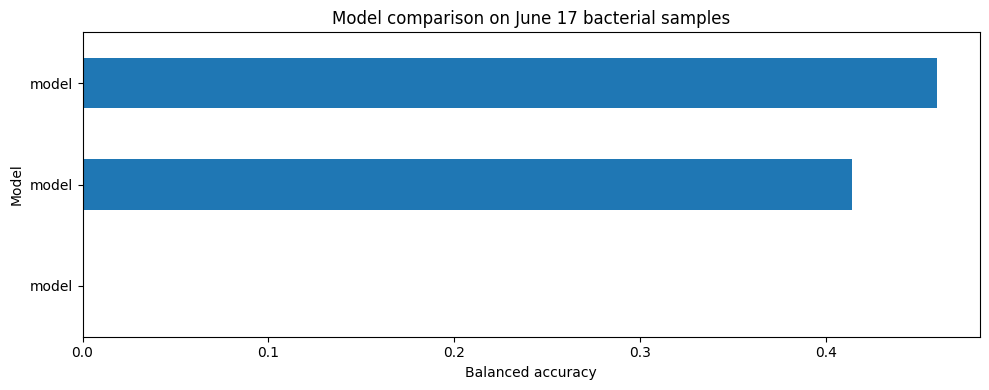

In [54]:
if MATPLOTLIB_AVAILABLE and not comparison.empty and "balanced_accuracy" in comparison.columns:
    plot_df = comparison.dropna(subset=["balanced_accuracy"]).copy()

    if not plot_df.empty:
        ax = plot_df.sort_values("balanced_accuracy").plot(
            kind="barh",
            x="model_id",
            y="balanced_accuracy",
            legend=False,
            figsize=(10, max(4, 0.45 * len(plot_df))),
        )
        ax.set_xlabel("Balanced accuracy")
        ax.set_ylabel("Model")
        ax.set_title("Model comparison on June 17 bacterial samples")
        plt.tight_layout()

        plot_path = RESULTS_DIR / "june17_bacterial_model_balanced_accuracy.png"
        plt.savefig(plot_path, dpi=200)
        print("Saved plot:", plot_path)
        plt.show()
